In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [59]:
# Importação do dataset
df = pd.read_csv("mecaniqa_dataset.csv")

# Preparação dos dados
df.columns = df.columns.str.strip()

df["Data"] = pd.to_datetime(
    df["Data"],
    format="%Y-%m-%d",
    errors="raise"
)

df = df.set_index("Data")
df = df.sort_index()

df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [60]:
df.describe()

,Trocas_Oleo,Manutencao_Motor
count,725.000000,728.000000
mean,26.020690,10.179945
std,11.620655,5.419338
min,0.000000,-2.000000
25%,18.000000,7.000000
50%,26.000000,10.000000
75%,33.000000,13.000000
max,150.000000,85.000000


Tratamento de Dados Ausentes


In [61]:
df["Trocas_Oleo"] = df["Trocas_Oleo"].interpolate()
df["Manutencao_Motor"] = df["Manutencao_Motor"].interpolate()

df.isnull().sum()

Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

Visualização da Série Temporal

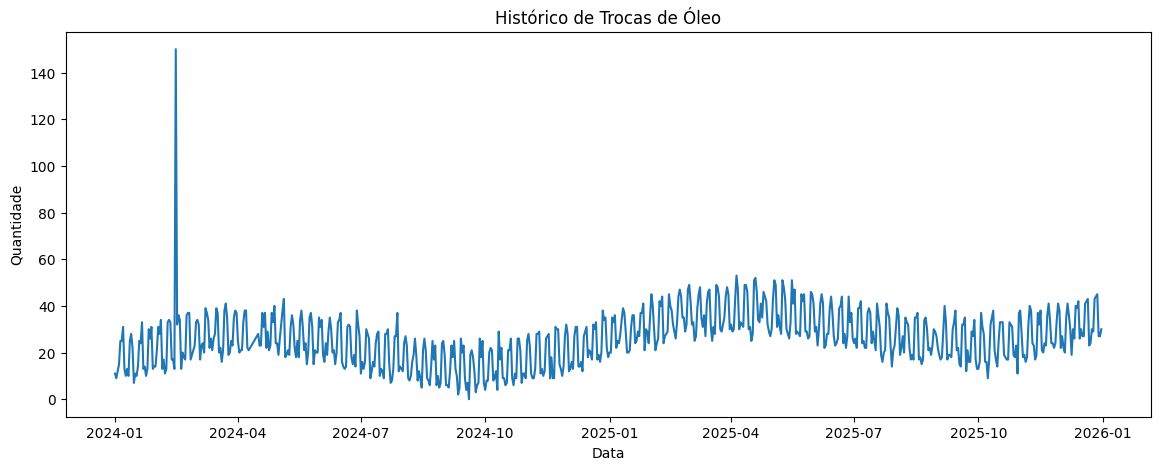

In [62]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Trocas_Oleo"])

plt.title("Histórico de Trocas de Óleo")
plt.xlabel("Data")
plt.ylabel("Quantidade")

plt.show()

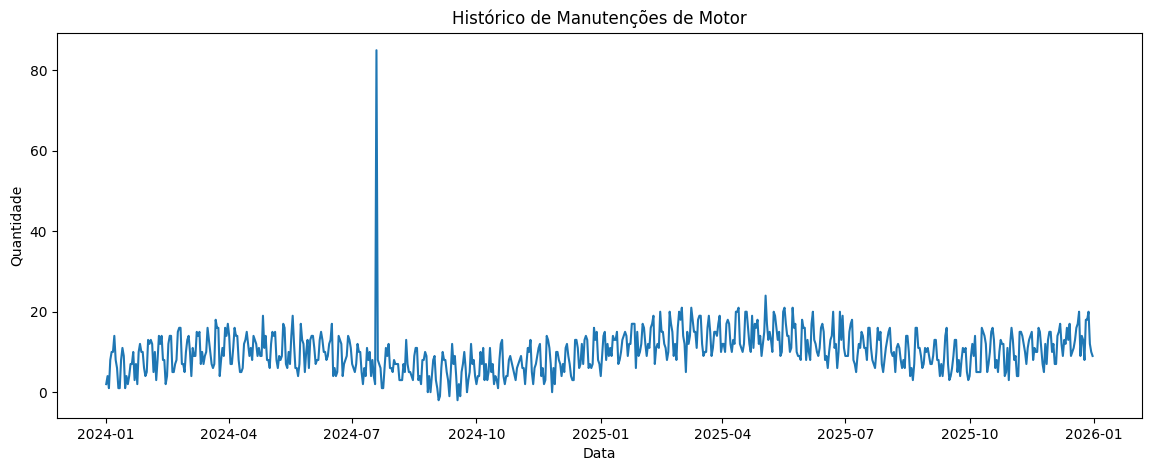

In [63]:
plt.figure(figsize=(14, 5))

plt.plot(df.index, df["Manutencao_Motor"])

plt.title("Histórico de Manutenções de Motor")
plt.xlabel("Data")
plt.ylabel("Quantidade")

plt.show()

Agora vamos normalizar para remover os outliers

In [64]:
# Corrigir valores negativos
df["Manutencao_Motor"] = df["Manutencao_Motor"].clip(lower=0)

# Limitar valores muito altos
df["Trocas_Oleo"] = df["Trocas_Oleo"].clip(upper=55)
df["Manutencao_Motor"] = df["Manutencao_Motor"].clip(upper=26)

E analisar a Média Temporal

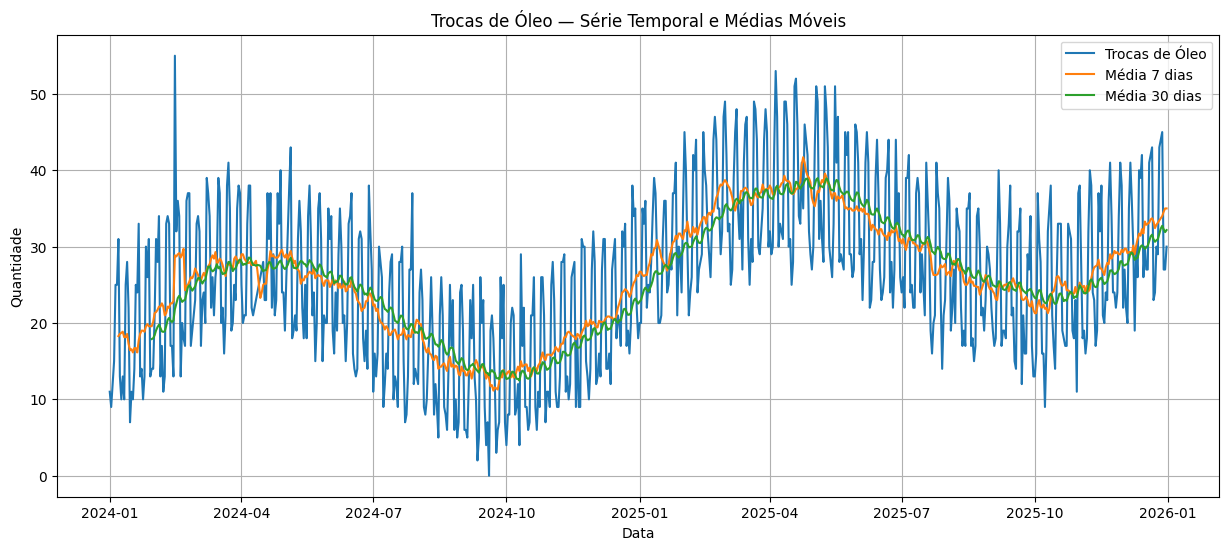

In [65]:
# Trocas de Óleo
df["Media_7_dias_Oleo"] = df["Trocas_Oleo"].rolling(window=7).mean()
df["Media_30_dias_Oleo"] = df["Trocas_Oleo"].rolling(window=30).mean()

# Manutenção de Motor
df["Media_7_dias_Motor"] = df["Manutencao_Motor"].rolling(window=7).mean()
df["Media_30_dias_Motor"] = df["Manutencao_Motor"].rolling(window=30).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Trocas_Oleo"],
    label="Trocas de Óleo"
)

plt.plot(
    df.index,
    df["Media_7_dias_Oleo"],
    label="Média 7 dias"
)

plt.plot(
    df.index,
    df["Media_30_dias_Oleo"],
    label="Média 30 dias"
)

plt.title("Trocas de Óleo — Série Temporal e Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)

plt.show()

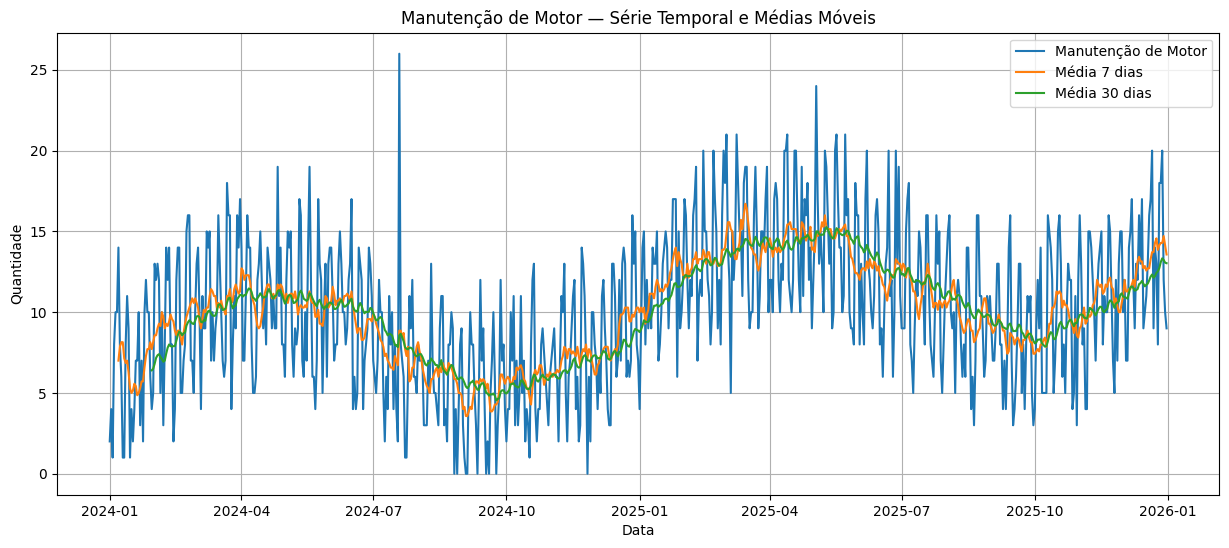

In [66]:
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Manutencao_Motor"],
    label="Manutenção de Motor"
)

plt.plot(
    df.index,
    df["Media_7_dias_Motor"],
    label="Média 7 dias"
)

plt.plot(
    df.index,
    df["Media_30_dias_Motor"],
    label="Média 30 dias"
)

plt.title("Manutenção de Motor — Série Temporal e Médias Móveis")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)

plt.show()

In [67]:
# Decisões do brainstorm
modelo_escolhido = "additive"
periodo_escolhido = 7

# Média móvel de sete dias
serie_oleo = df["Trocas_Oleo"]
serie_motor = df["Manutencao_Motor"]
media_movel_7_dias = serie_oleo.rolling(
    window=periodo_escolhido,
    center=True
).mean()

print("\nPrimeiros valores da média móvel:")
display(media_movel_7_dias.dropna().head())


Primeiros valores da média móvel:


Data
2024-01-04    18.285714
2024-01-05    18.571429
2024-01-06    18.714286
2024-01-07    18.857143
2024-01-08    18.142857
Name: Trocas_Oleo, dtype: float64

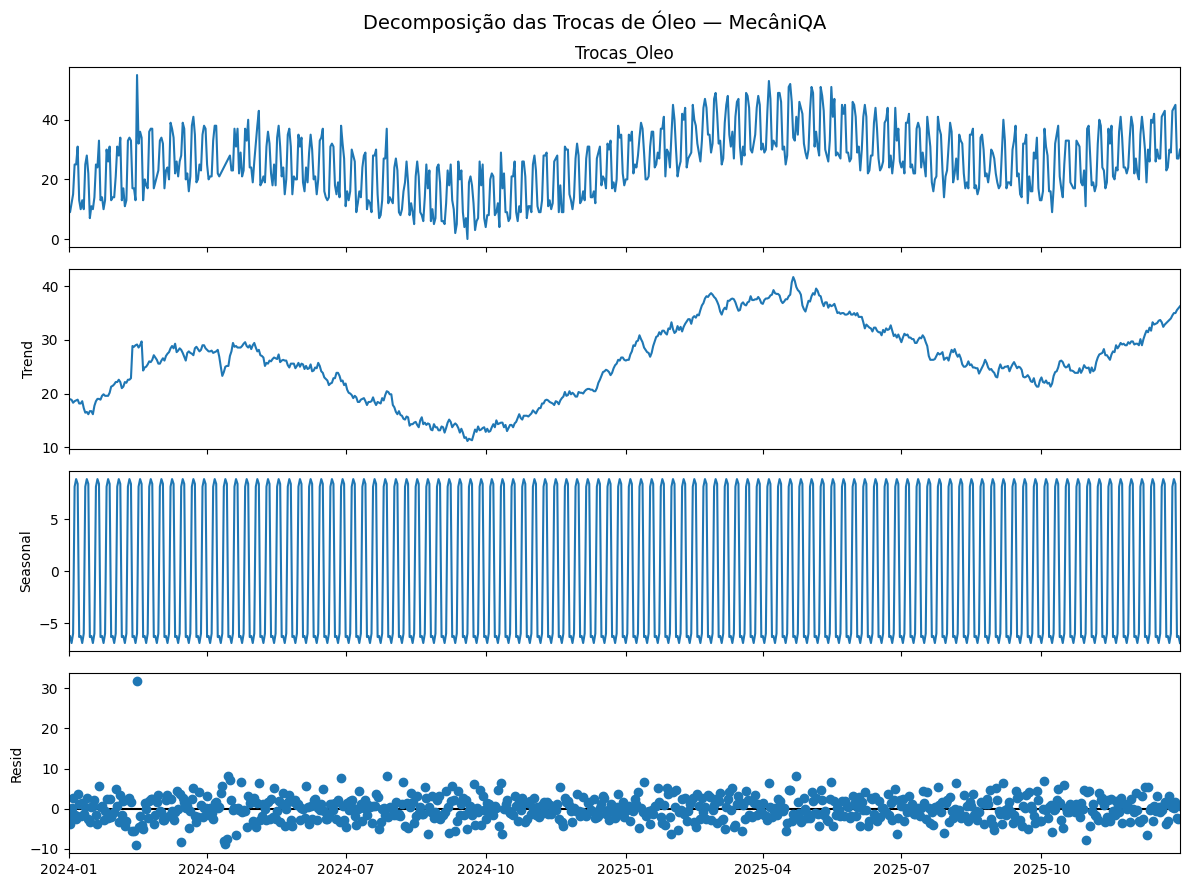

Modelo escolhido: additive
Período escolhido: 7 dias


In [68]:
# Decomposição temporal
resultado = seasonal_decompose(
    serie_oleo,
    model=modelo_escolhido,
    period=periodo_escolhido,
    extrapolate_trend=periodo_escolhido
)

# Gera os quatro gráficos
fig = resultado.plot()

fig.set_size_inches(12, 9)
fig.suptitle(
    "Decomposição das Trocas de Óleo — MecâniQA",
    fontsize=14
)

fig.tight_layout()
plt.show()

print("Modelo escolhido:", modelo_escolhido)
print("Período escolhido:", periodo_escolhido, "dias")

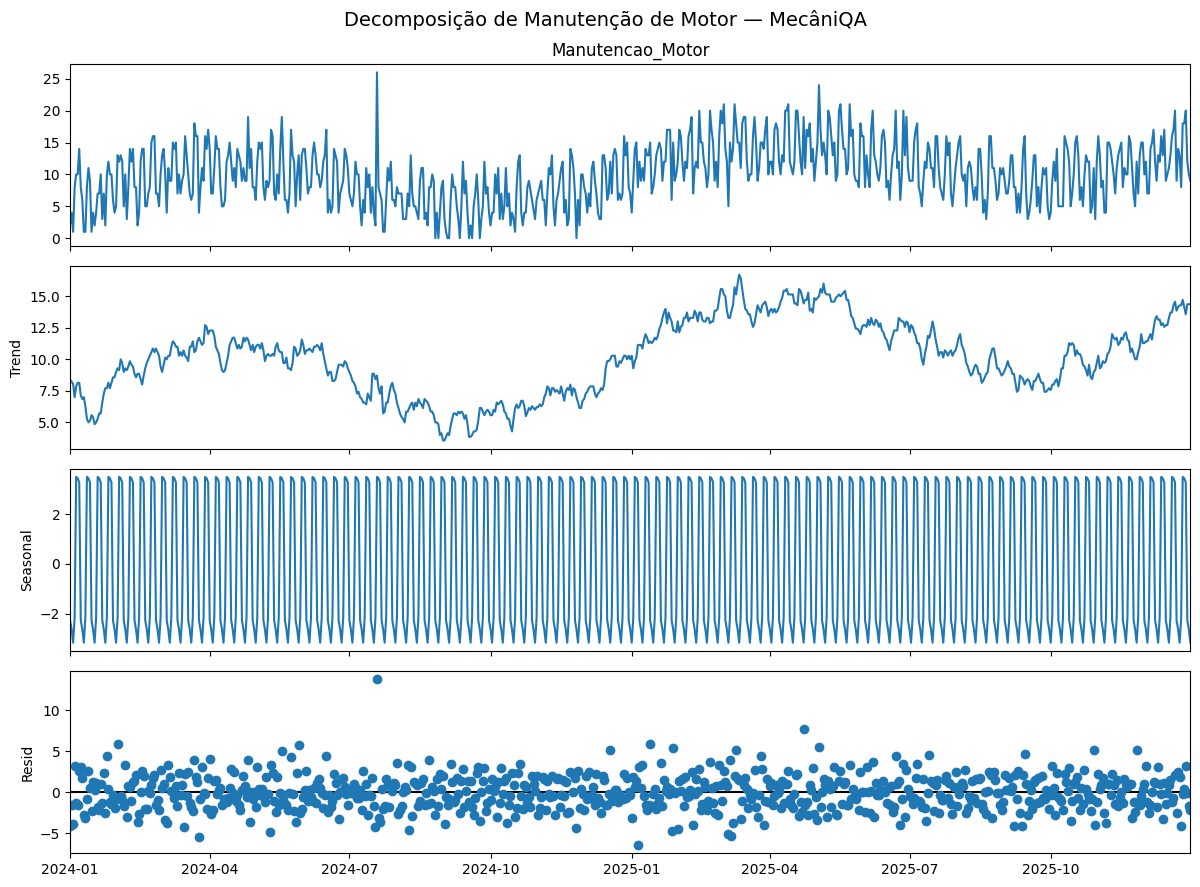

Modelo escolhido: additive
Período escolhido: 7 dias


In [69]:
# Decomposição temporal
resultado = seasonal_decompose(
    serie_motor,
    model=modelo_escolhido,
    period=periodo_escolhido,
    extrapolate_trend=periodo_escolhido
)

# Gera os quatro gráficos
fig = resultado.plot()

fig.set_size_inches(12, 9)
fig.suptitle(
    "Decomposição de Manutenção de Motor — MecâniQA",
    fontsize=14
)

fig.tight_layout()
plt.show()

print("Modelo escolhido:", modelo_escolhido)
print("Período escolhido:", periodo_escolhido, "dias")

Modelos

In [86]:
def modelo_naive(serie):
    return serie.shift(1)

def modelo_media_movel(serie, janela):
    return serie.shift(1).rolling(window=janela).mean()

df["Previsao_Naive_Oleo"] = modelo_naive(df["Trocas_Oleo"])

df["Previsao_Media_7_Oleo"] = modelo_media_movel(
    df["Trocas_Oleo"],
    janela=7
)

df["Previsao_Media_30_Oleo"] = modelo_media_movel(
    df["Trocas_Oleo"],
    janela=30
)

df["Previsao_Naive_Motor"] = modelo_naive(df["Manutencao_Motor"])

df["Previsao_Media_7_Motor"] = modelo_media_movel(
    df["Manutencao_Motor"],
    janela=7
)

df["Previsao_Media_30_Motor"] = modelo_media_movel(
    df["Manutencao_Motor"],
    janela=30
)

In [87]:
display(
    df[
        [
            "Trocas_Oleo",
            "Previsao_Naive_Oleo",
            "Previsao_Media_7_Oleo",
            "Previsao_Media_30_Oleo"
        ]
    ].tail(10)
)

,Trocas_Oleo,Previsao_Naive_Oleo,Previsao_Media_7_Oleo,Previsao_Media_30_Oleo
Data,,,,
2025-12-22,23.0,43.0,33.714286,31.566667
2025-12-23,24.0,23.0,33.285714,30.966667
2025-12-24,30.0,24.0,32.428571,30.633333
2025-12-25,29.0,30.0,32.857143,30.833333
2025-12-26,43.0,29.0,33.142857,31.000000
2025-12-27,44.0,43.0,33.428571,31.700000
2025-12-28,45.0,44.0,33.714286,32.366667
2025-12-29,27.0,45.0,34.000000,32.733333
2025-12-30,27.0,27.0,34.571429,32.266667


GRÁFICOS


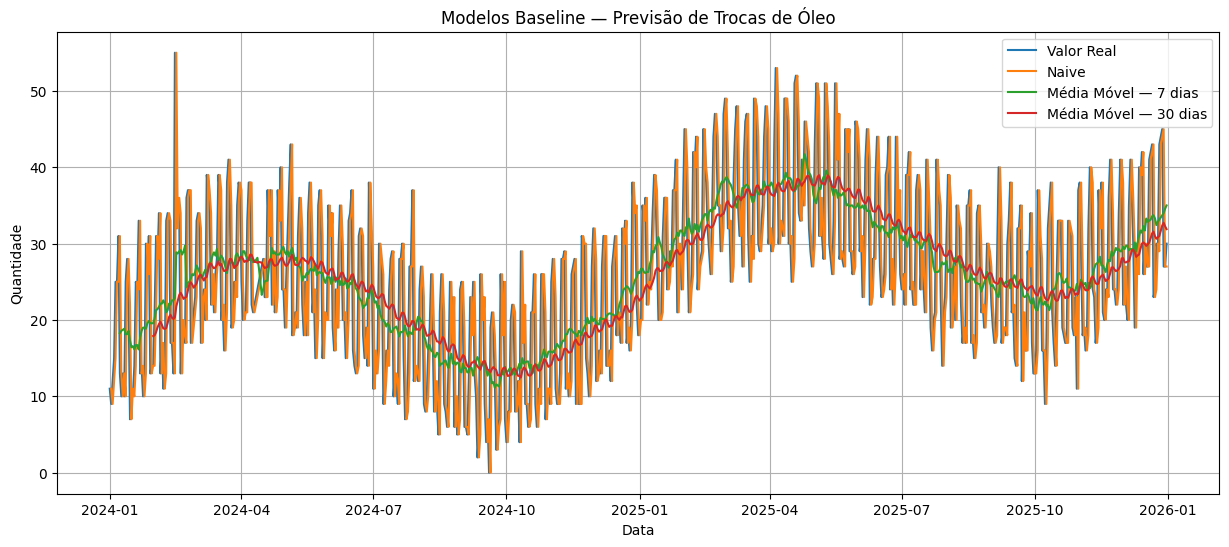

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Trocas_Oleo"],
    label="Valor Real"
)

plt.plot(
    df.index,
    df["Previsao_Media_7_Oleo"],
    label="Média Móvel — 7 dias"
)

plt.plot(
    df.index,
    df["Previsao_Media_30_Oleo"],
    label="Média Móvel — 30 dias"
)

plt.title("Modelos Baseline — Previsão de Trocas de Óleo")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.legend()
plt.grid(True)
plt.show()

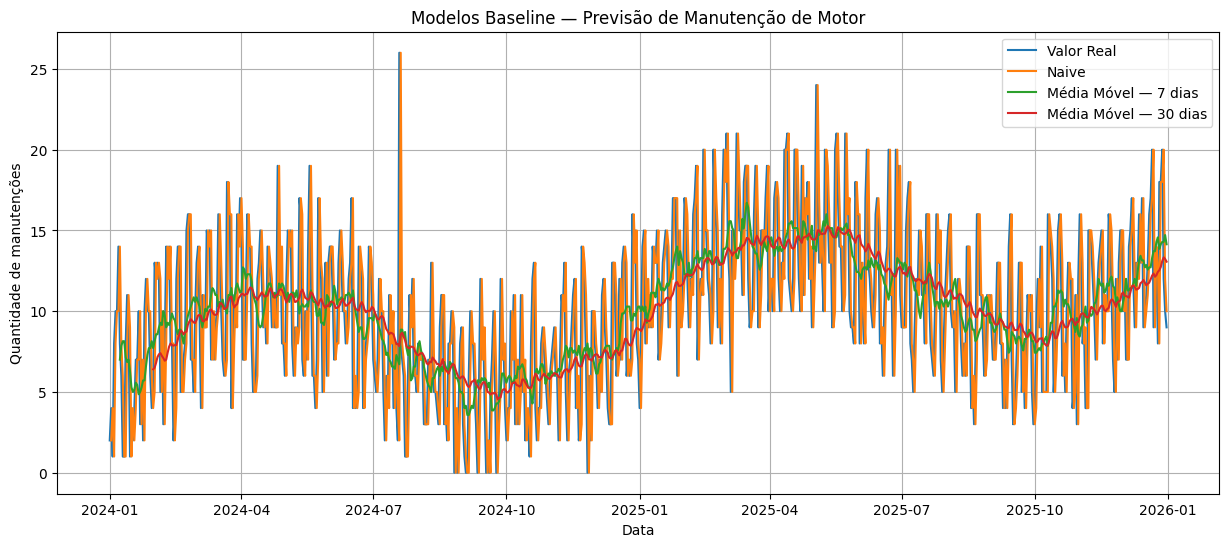

In [ ]:

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Manutencao_Motor"],
    label="Valor Real"
)

plt.plot(
    df.index,
    df["Previsao_Media_7_Motor"],
    label="Média Móvel — 7 dias"
)

plt.plot(
    df.index,
    df["Previsao_Media_30_Motor"],
    label="Média Móvel — 30 dias"
)

plt.title("Modelos Baseline — Previsão de Manutenção de Motor")
plt.xlabel("Data")
plt.ylabel("Quantidade de manutenções")
plt.legend()
plt.grid(True)
plt.show()